<p style="font-size:300%; background-color:#ffe6f0; color:#0044cc; text-align:center; line-height:80px; margin:0; padding:0;">
  <b>Aprendizaje de Máquina</b>
</p>

<p style="font-size:240%; background-color:#ffe6f0; color:#cc0000; text-align:center; line-height:60px; margin:0; padding:0;">
  <b>Técnicas de Inteligencia Artificial</b>
</p>

<p style="font-size:200%; text-align:center; line-height:40px; margin:0;">
  <br><b>Prof. Flavio Prieto</b>
</p>

<p style="font-size:160%; text-align:center; line-height:25px; margin:0;">
  email: <a href="mailto:faprietoo@unal.edu.co">faprietoo@unal.edu.co</a>
</p>

<p style="font-size:180%; text-align:center; line-height:30px; margin:0;">
  <br><b>DEPARTAMENTO DE INGENIERÍA MECÁNICA Y MECATRÓNICA</b>
</p>

<p style="font-size:180%; text-align:center; line-height:30px; margin:0;">
  Facultad de Ingeniería
</p>

<p style="font-size:160%; text-align:center; line-height:30px; margin:0;">
  Universidad Nacional de Colombia – Sede Bogotá
</p>

<div style="text-align:center; margin-top:20px; margin-bottom:10px;">
  <img src="Fig/Escudo_UN.png" alt="Escudo UNAL" width="90" style="border:none;">
</div>

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color: #e8f5e9; text-align: center;">
  <strong style="font-size: 32px;">APRENDIZAJE NO SUPERVISADO</strong>
</div>

# K-Means

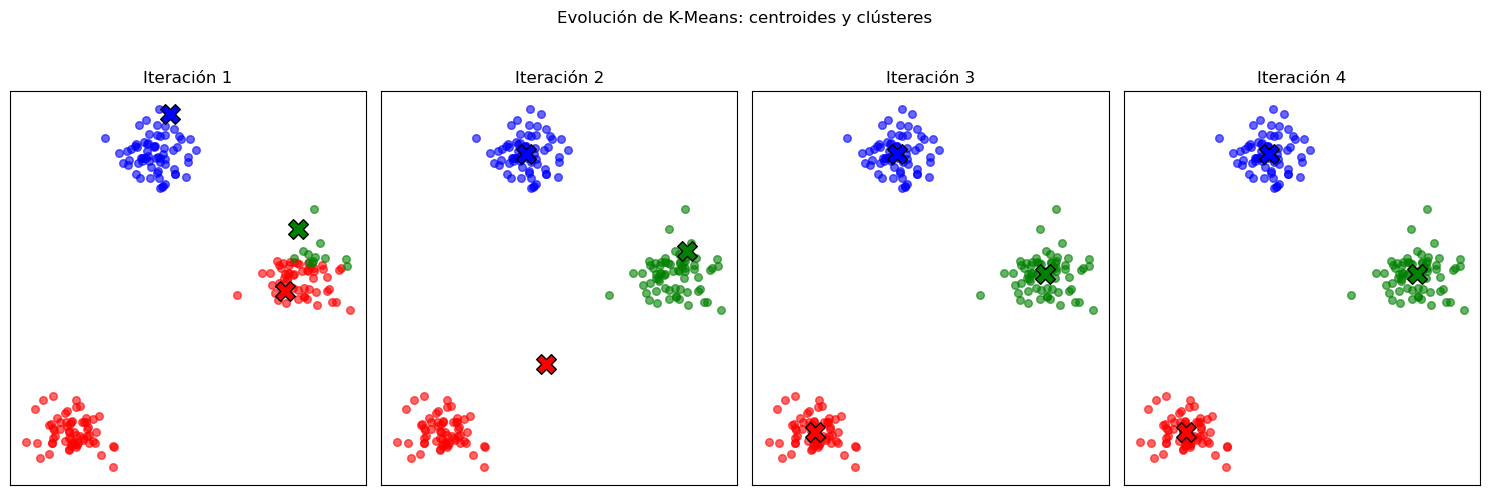

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# -----------------------------
# Generar datos de ejemplo
# -----------------------------
X, y_true = make_blobs(n_samples=200, centers=3, cluster_std=1.0, random_state=42)

# -----------------------------
# Configurar KMeans
# -----------------------------
K = 3
kmeans = KMeans(n_clusters=K, init='random', n_init=1, max_iter=1, random_state=42, algorithm='full')

# -----------------------------
# Mostrar evolución iterativa
# -----------------------------
plt.figure(figsize=(15, 5))

# Vamos a almacenar los centroides
centroids_list = []

# Iteramos manualmente para capturar cada paso
X_copy = X.copy()
centroids = X_copy[np.random.choice(range(X_copy.shape[0]), K, replace=False)]
centroids_list.append(centroids)

for iteration in range(4):  # mostrar 4 iteraciones
    # Asignar clústeres
    distances = np.linalg.norm(X_copy[:, np.newaxis] - centroids[np.newaxis, :], axis=2)
    labels = np.argmin(distances, axis=1)
    
    # Graficar
    plt.subplot(1, 4, iteration+1)
    colors = ['red', 'blue', 'green']
    for k in range(K):
        plt.scatter(X_copy[labels==k, 0], X_copy[labels==k, 1], s=30, color=colors[k], alpha=0.6)
        plt.scatter(centroids[k, 0], centroids[k, 1], color=colors[k], marker='X', s=200, edgecolor='k')
    plt.title(f'Iteración {iteration+1}')
    plt.xticks([])
    plt.yticks([])
    
    # Actualizar centroides
    new_centroids = np.array([X_copy[labels==k].mean(axis=0) for k in range(K)])
    centroids = new_centroids
    centroids_list.append(centroids)

plt.suptitle('Evolución de K-Means: centroides y clústeres')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


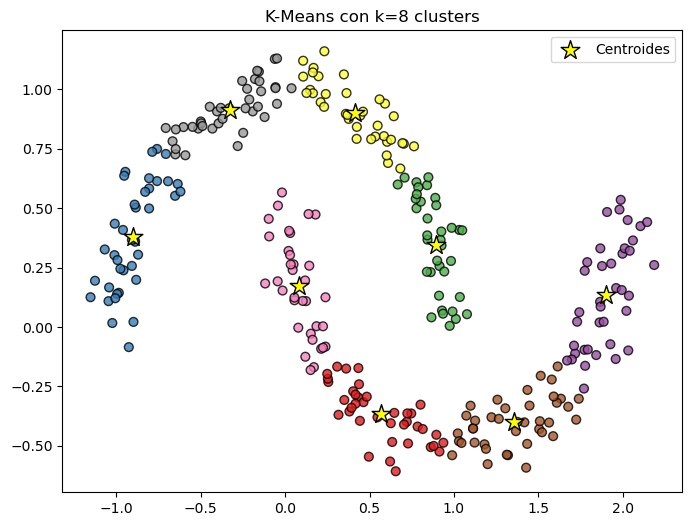

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

# ================================
# Generar datos de ejemplo
# ================================
X, _ = make_moons(n_samples=300, noise=0.07, random_state=42)

# ================================
# Aplicar K-Means
# ================================
k = 8  # número de clusters esperado
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

# ================================
# Visualización de clusters
# ================================
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="Set1", s=40, edgecolor="k", alpha=0.8)
plt.scatter(centroids[:, 0], centroids[:, 1], 
            c="yellow", s=200, marker="*", edgecolor="k", label="Centroides")
plt.title(f"K-Means con k={k} clusters")
plt.legend()
plt.show()


# Agrupamiento Jerárquico (Hierarchical Clustering)

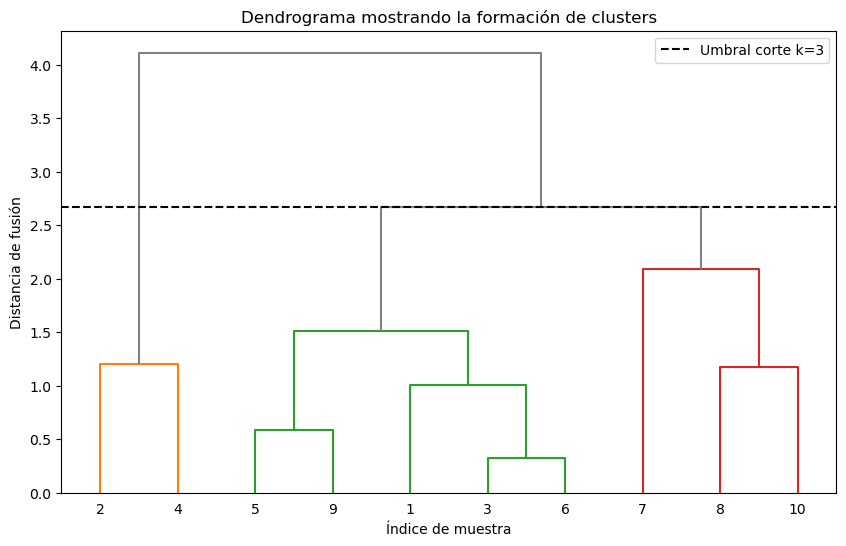

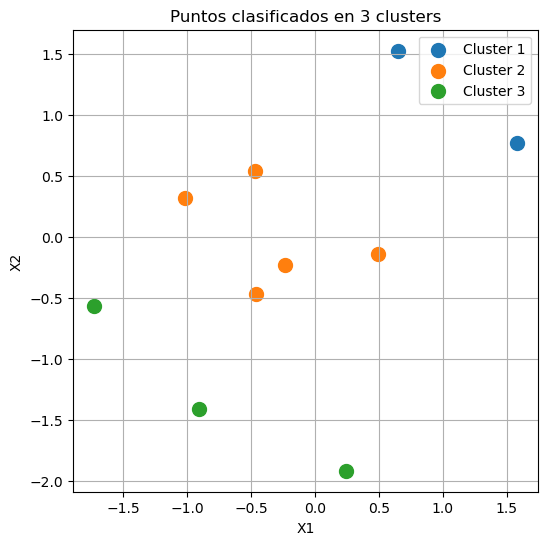

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Generar datos de ejemplo (2D)
np.random.seed(42)
X = np.random.randn(10, 2)

# Calcular linkage
Z = linkage(X, method='ward')

# Elegir número de clusters
k = 3
clusters = fcluster(Z, k, criterion='maxclust')

# Determinar altura para colorear los clusters en el dendrograma
color_thresh = Z[-(k-1), 2]

# Dibujar dendrograma
plt.figure(figsize=(10, 6))
dendro = dendrogram(Z, labels=np.arange(1, X.shape[0]+1),
                    leaf_rotation=0, leaf_font_size=10,
                    color_threshold=color_thresh, above_threshold_color='grey')
plt.axhline(y=color_thresh, c='k', linestyle='--', label=f'Umbral corte k={k}')
plt.title('Dendrograma mostrando la formación de clusters')
plt.xlabel('Índice de muestra')
plt.ylabel('Distancia de fusión')
plt.legend()
plt.show()

# Dibujar los puntos clasificados en 2D
plt.figure(figsize=(6, 6))
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']  # Colores para clusters
for i in range(1, k+1):
    plt.scatter(X[clusters == i, 0], X[clusters == i, 1], 
                label=f'Cluster {i}', s=100)

plt.title(f'Puntos clasificados en {k} clusters')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True)
plt.show()


### Dos umbrales de corte

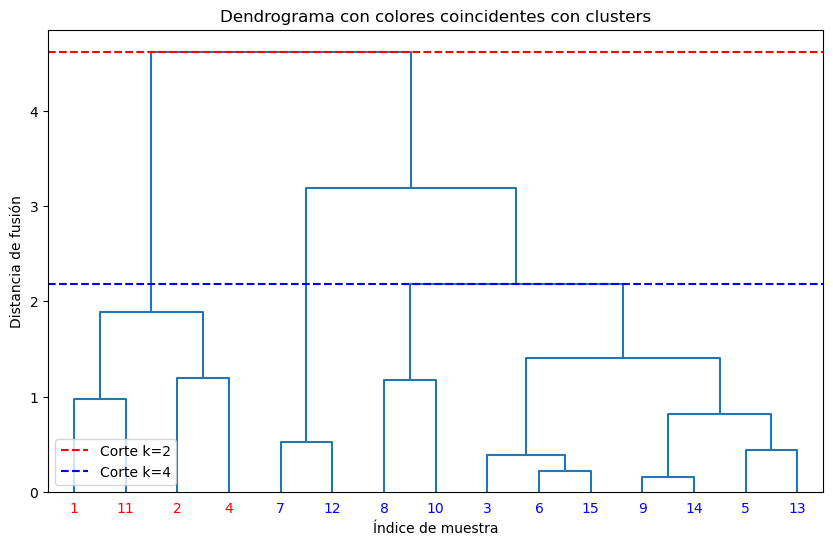

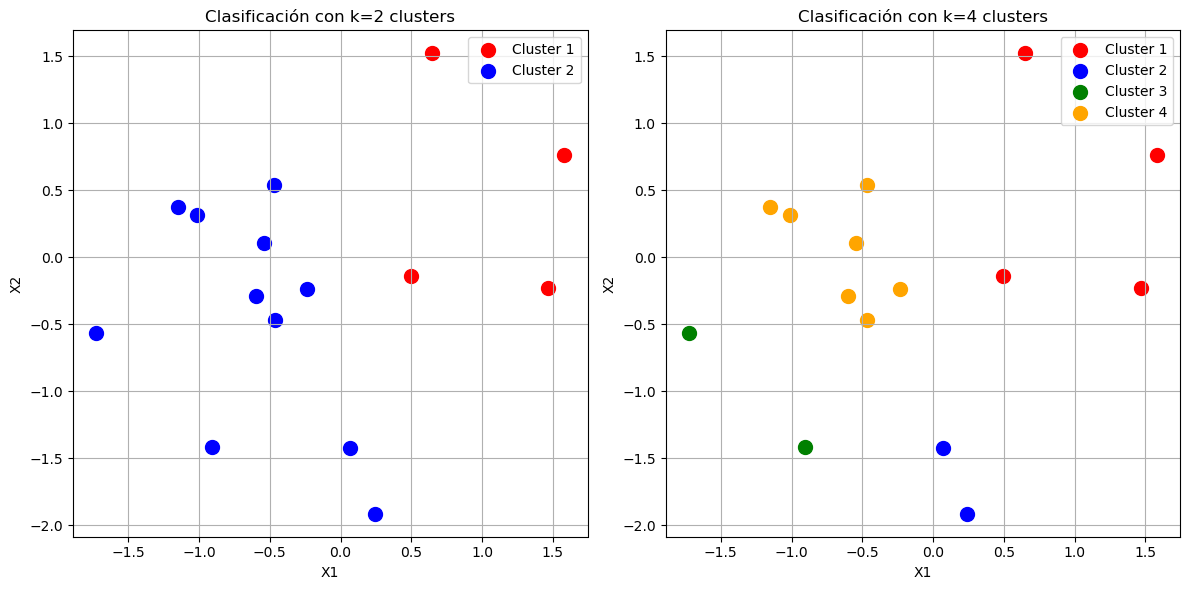

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Generar datos de ejemplo (2D)
np.random.seed(42)
X = np.random.randn(15, 2)

# Calcular la matriz de enlaces (linkage) usando método 'ward'
Z = linkage(X, method='ward')

# Definir dos números de clusters distintos
k1, k2 = 2, 4

# Generar clusters para ambos cortes
clusters1 = fcluster(Z, k1, criterion='maxclust')
clusters2 = fcluster(Z, k2, criterion='maxclust')

# Asignar colores a cada cluster
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']

# Función para recolorear las hojas según cluster
def recolor_leaves(ax, clusters):
    xlbls = ax.get_xmajorticklabels()
    for lbl in xlbls:
        idx = int(lbl.get_text()) - 1
        lbl.set_color(colors[clusters[idx]-1])

# Dibujar dendrograma
plt.figure(figsize=(10, 6))
dendro = dendrogram(Z, labels=np.arange(1, X.shape[0]+1),
                    leaf_rotation=0, leaf_font_size=10,
                    color_threshold=0)  # desactivar coloreado automático

# Recolorear las hojas según corte 1 (k1)
ax = plt.gca()
recolor_leaves(ax, clusters1)

# Añadir líneas de corte
color_thresh1 = Z[-(k1-1), 2]
color_thresh2 = Z[-(k2-1), 2]
plt.axhline(y=color_thresh1, c='red', linestyle='--', label=f'Corte k={k1}')
plt.axhline(y=color_thresh2, c='blue', linestyle='--', label=f'Corte k={k2}')

plt.title('Dendrograma con colores coincidentes con clusters')
plt.xlabel('Índice de muestra')
plt.ylabel('Distancia de fusión')
plt.legend()
plt.show()

# Dibujar puntos clasificados para ambos cortes
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Corte 1
for i in range(1, k1+1):
    axes[0].scatter(X[clusters1 == i, 0], X[clusters1 == i, 1],
                    label=f'Cluster {i}', s=100, color=colors[i-1])
axes[0].set_title(f'Clasificación con k={k1} clusters')
axes[0].set_xlabel('X1')
axes[0].set_ylabel('X2')
axes[0].legend()
axes[0].grid(True)

# Corte 2
for i in range(1, k2+1):
    axes[1].scatter(X[clusters2 == i, 0], X[clusters2 == i, 1],
                    label=f'Cluster {i}', s=100, color=colors[i-1])
axes[1].set_title(f'Clasificación con k={k2} clusters')
axes[1].set_xlabel('X1')
axes[1].set_ylabel('X2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### Ejemplo con datos no lieneales

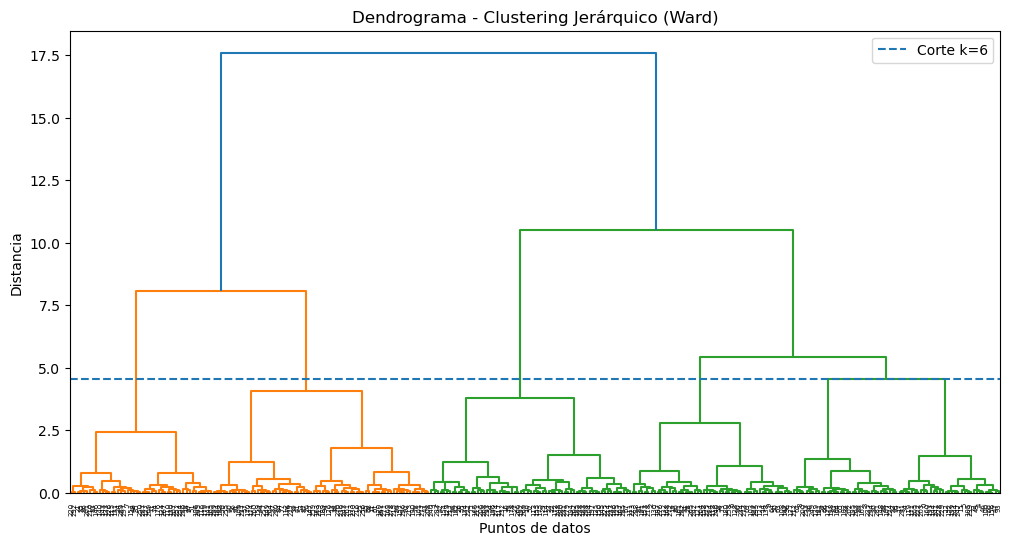

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# ================================
# Generar datos de ejemplo
# ================================
X, _ = make_moons(n_samples=300, noise=0.07, random_state=42)

# ================================
# Clustering jerárquico
# ================================
# Calcular la matriz de enlaces (linkage)
Z = linkage(X, method="ward")  # Ward minimiza varianza intra-clúster


# ================================
# Seleccionar número de clusters
# ================================
k = 6  # queremos separar en 2 clústeres (forma de luna)
labels = fcluster(Z, k, criterion="maxclust")

# ================================
# Dendrograma con línea de corte
# ================================
plt.figure(figsize=(12, 6))

dendrogram(Z, truncate_mode="level", p=10, leaf_rotation=90)

# Obtener la altura de corte para k clusters
# Ordenamos las distancias de fusión
distances = Z[:, 2]
distances_sorted = np.sort(distances)

# El corte está en la fusión que deja k clusters
# (n - k)-ésima fusión
n = X.shape[0]
cut_height = distances_sorted[-(k - 1)]

# Dibujar línea horizontal
plt.axhline(y=cut_height, linestyle="--", label=f"Corte k={k}")

plt.title("Dendrograma - Clustering Jerárquico (Ward)")
plt.xlabel("Puntos de datos")
plt.ylabel("Distancia")
plt.legend()

plt.show()

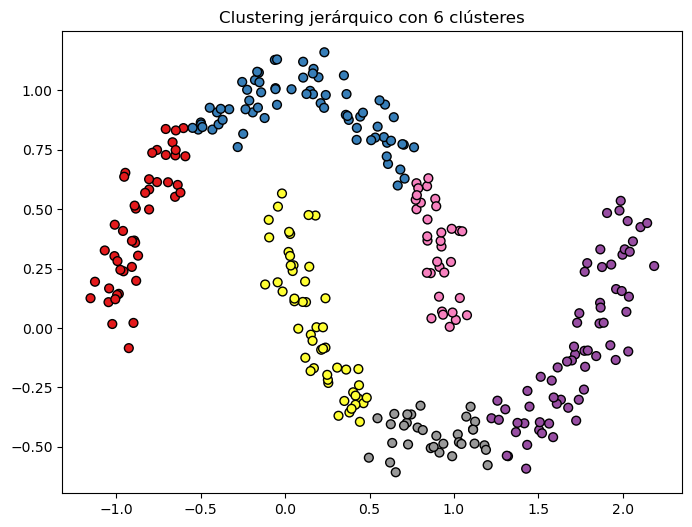

In [12]:
# ================================
# Visualización de clusters
# ================================
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="Set1", s=40, edgecolor="k")
plt.title(f"Clustering jerárquico con {k} clústeres")
plt.show()

# Clustering con DBSCAN

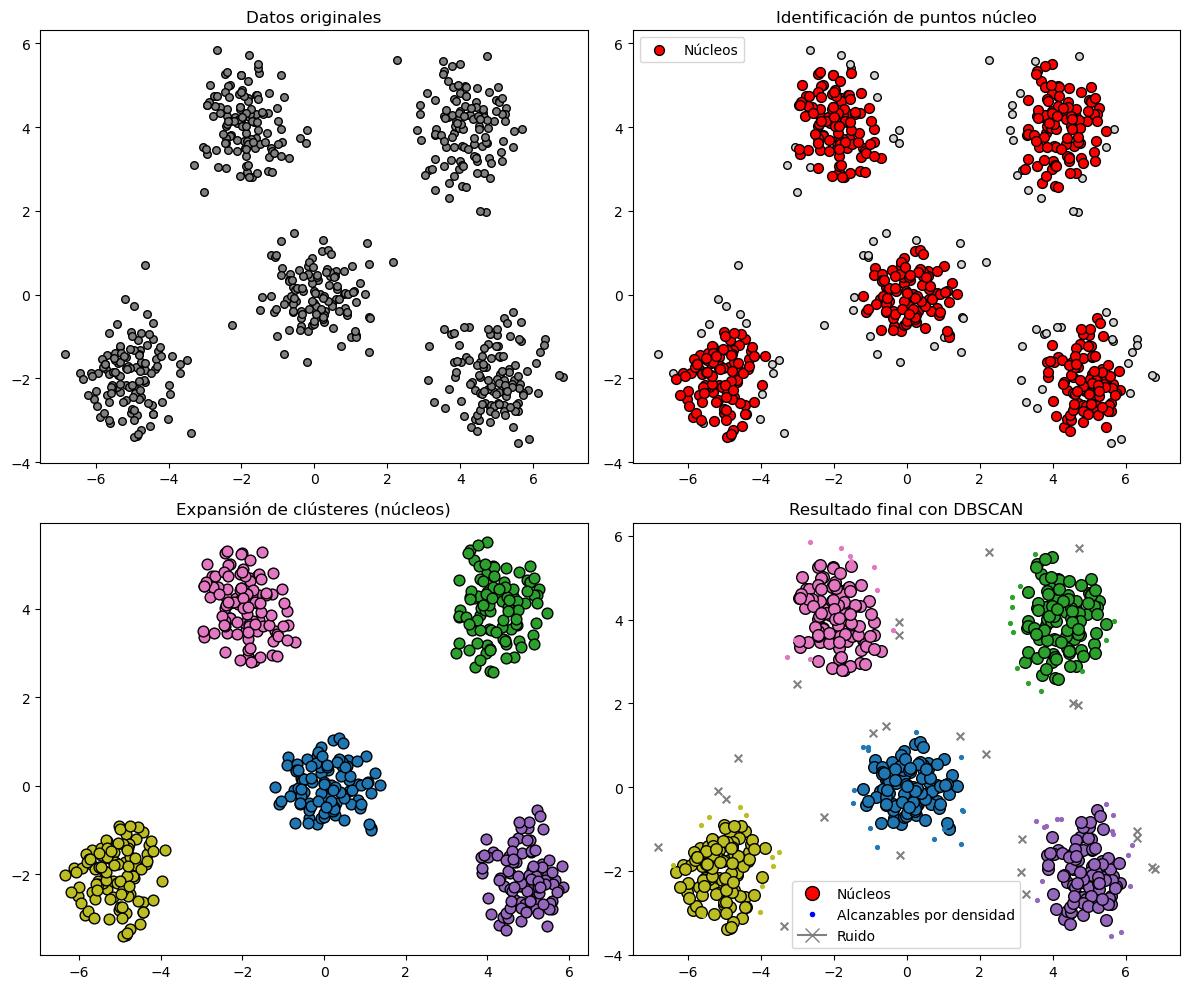

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

# =========================
# Generar datos de ejemplo
# =========================
centros = [(-5, -2), (0, 0), (5, -2), (-2, 4), (4, 4)]
X, _ = make_blobs(n_samples=600, centers=centros, cluster_std=0.7, random_state=42)

# =========================
# Aplicar DBSCAN
# =========================
eps = 0.6       # radio de vecindad
min_samples = 8 # mínimo de puntos para clúster
db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X)

# Índices de núcleos
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

# =========================
# Visualización paso a paso
# =========================
unique_labels = set(labels)
colors = [plt.cm.tab10(each) for each in np.linspace(0, 1, len(unique_labels))]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- (a) Datos originales
axes[0, 0].scatter(X[:, 0], X[:, 1], c="gray", s=30, edgecolor="k")
axes[0, 0].set_title("Datos originales")

# --- (b) Núcleos detectados
axes[0, 1].scatter(X[:, 0], X[:, 1], c="lightgray", s=30, edgecolor="k")
axes[0, 1].scatter(X[core_samples_mask, 0], X[core_samples_mask, 1],
                   c="red", s=50, edgecolor="k", label="Núcleos")
axes[0, 1].legend()
axes[0, 1].set_title("Identificación de puntos núcleo")

# --- (c) Expansión de clústeres
for k, col in zip(unique_labels, colors):
    if k == -1:
        continue
    class_member_mask = (labels == k)
    xy_core = X[class_member_mask & core_samples_mask]
    axes[1, 0].scatter(xy_core[:, 0], xy_core[:, 1], c=[col], s=60, marker="o", edgecolor="k")
axes[1, 0].set_title("Expansión de clústeres (núcleos)")

# --- (d) Resultado final con ruido y leyenda
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0.6, 0.6, 0.6, 1]  # ruido en gris
    class_member_mask = (labels == k)

    # Núcleos
    xy = X[class_member_mask & core_samples_mask]
    axes[1, 1].scatter(xy[:, 0], xy[:, 1], c=[col], s=70, marker="o", edgecolor="k", label=None)

    # Alcanzables por densidad
    xy = X[class_member_mask & ~core_samples_mask & (labels != -1)]
    axes[1, 1].scatter(xy[:, 0], xy[:, 1], c=[col], s=30, marker=".", label=None)

    # Ruido
    xy = X[class_member_mask & (labels == -1)]
    axes[1, 1].scatter(xy[:, 0], xy[:, 1], c="gray", s=30, marker="x", label=None)

# Construir leyenda personalizada
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Núcleos',
           markerfacecolor='red', markeredgecolor='k', markersize=10),
    Line2D([0], [0], marker='.', color='w', label='Alcanzables por densidad',
           markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='x', color='gray', label='Ruido',
           markeredgecolor='gray', markersize=10)
]
axes[1, 1].legend(handles=legend_elements, loc="best")
axes[1, 1].set_title("Resultado final con DBSCAN")

plt.tight_layout()
plt.show()


## Otro ejemplo 

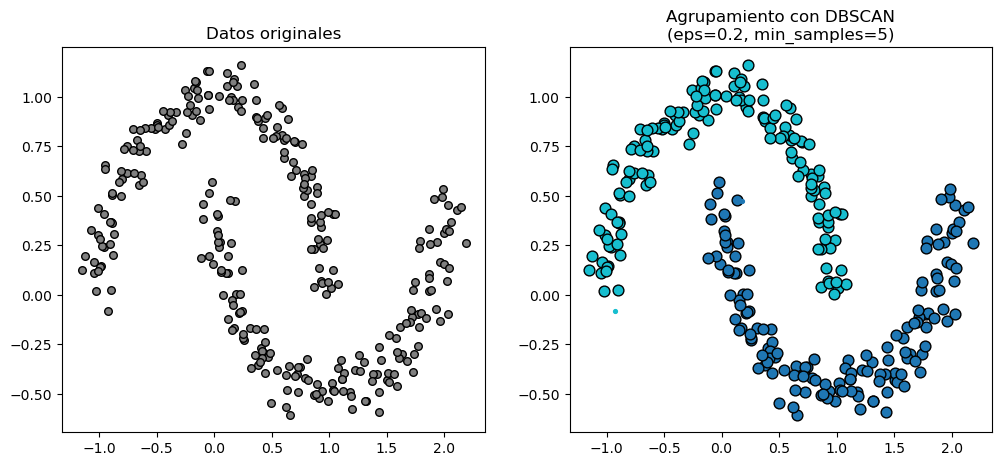

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

# Generar datos de ejemplo
X, _ = make_moons(n_samples=300, noise=0.07, random_state=42)

# Aplicar DBSCAN
eps = 0.2      # radio de vecindad
min_samples = 5  # mínimo de puntos para formar un clúster
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X)

# Identificar núcleos, bordes y ruido
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

# Puntos de ruido (label = -1)
noise_mask = labels == -1

# Colores de clústeres
unique_labels = set(labels)
colors = [plt.cm.tab10(each) for each in np.linspace(0, 1, len(unique_labels))]

# --- Visualización ---
plt.figure(figsize=(12, 5))

# Datos originales
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c="gray", s=30, edgecolor="k")
plt.title("Datos originales")

# Agrupamiento DBSCAN
plt.subplot(1, 2, 2)
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Ruido -> color negro
        col = [0, 0, 0, 1]
    class_member_mask = (labels == k)
    
    # Núcleos
    xy = X[class_member_mask & core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], s=60, marker="o", edgecolor="k")
    
    # Frontera
    xy = X[class_member_mask & ~core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], s=30, marker=".")
    
plt.title(f"Agrupamiento con DBSCAN\n(eps={eps}, min_samples={min_samples})")
plt.show()


# Clustering con Gaussian Mixture Models (GMM)

La técnica **Gaussian Mixture Models (GMM)** es un método probabilístico de agrupamiento que asume que los datos provienen de una combinación de varias distribuciones gaussianas. Cada clúster se modela como una distribución normal multivariada con sus propios parámetros de media y covarianza.

## Modelo probabilístico
El modelo supone que la distribución de los datos $x \in \mathbb{R}^d$ se puede representar como una mezcla de $K$ gaussianas:

$$
p(x) = \sum_{k=1}^K \pi_k \, \mathcal{N}(x \,|\, \mu_k, \Sigma_k),
$$

donde:
- $\pi_k$ son los **pesos de mezcla**, con $\pi_k \geq 0$ y $\sum_{k=1}^K \pi_k = 1$.
- $\mu_k$ es el vector de medias de la $k$-ésima gaussiana.
- $\Sigma_k$ es la matriz de covarianza de la $k$-ésima gaussiana.
- $\mathcal{N}(x \,|\, \mu_k, \Sigma_k)$ es la densidad de probabilidad de una gaussiana multivariada:

$$
\mathcal{N}(x \,|\, \mu, \Sigma) = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}} \exp\left( -\tfrac{1}{2}(x-\mu)^\top \Sigma^{-1} (x-\mu) \right).
$$

## Entrenamiento con EM (Expectation-Maximization)
Para estimar los parámetros $(\pi_k, \mu_k, \Sigma_k)$, se emplea el algoritmo **EM**, que alterna entre:

1. **E-step:** se calculan las responsabilidades, es decir, la probabilidad de que el punto $x_i$ pertenezca al clúster $k$:
$$
\gamma_{ik} = \frac{\pi_k \, \mathcal{N}(x_i \,|\, \mu_k, \Sigma_k)}{\sum_{j=1}^K \pi_j \, \mathcal{N}(x_i \,|\, \mu_j, \Sigma_j)}.
$$

2. **M-step:** se actualizan los parámetros usando las responsabilidades:
$$
N_k = \sum_{i=1}^N \gamma_{ik}, \quad
\mu_k = \frac{1}{N_k} \sum_{i=1}^N \gamma_{ik} x_i,
$$
$$
\Sigma_k = \frac{1}{N_k} \sum_{i=1}^N \gamma_{ik} (x_i - \mu_k)(x_i - \mu_k)^\top, \quad
\pi_k = \frac{N_k}{N}.
$$

## GMM Manual

### Los parámetros se incializan manuelmente

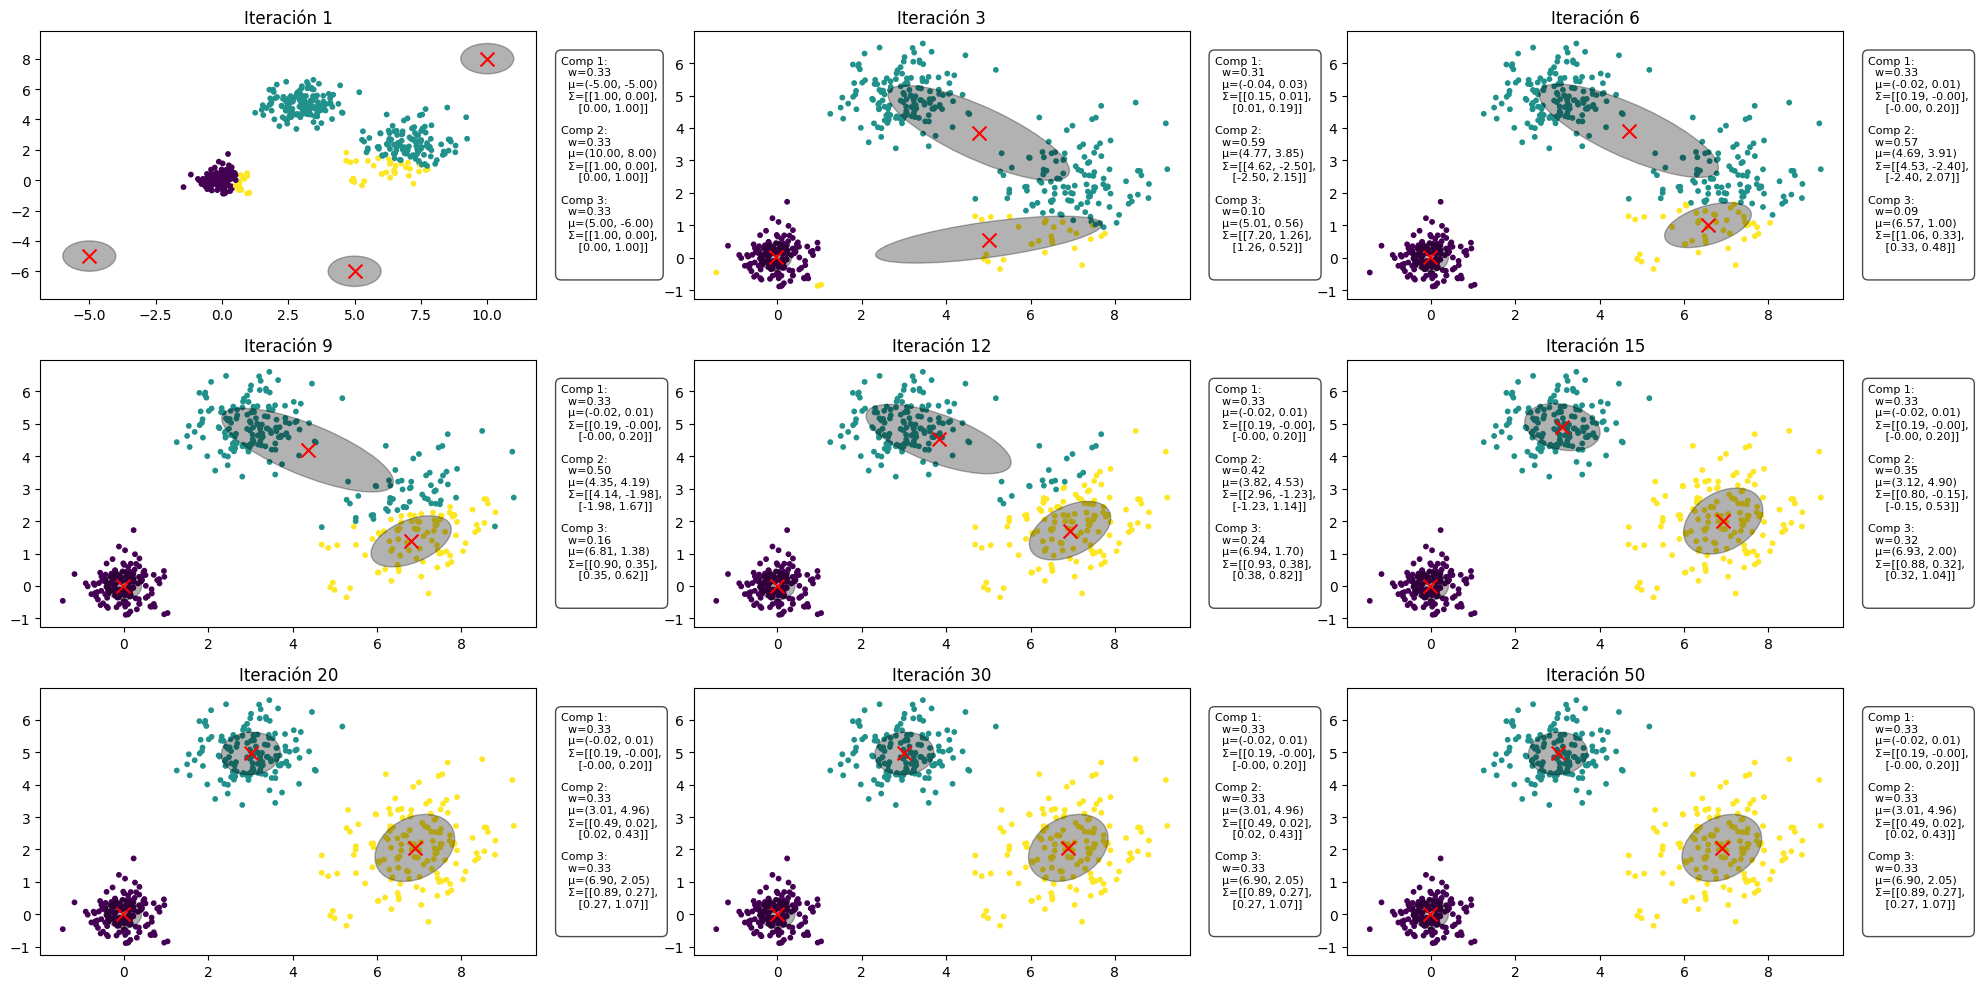

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal


# ==========================
# Datos de ejemplo (2D con 3 clusters)
# ==========================
np.random.seed(42)
X1 = np.random.multivariate_normal([0, 0], 0.2*np.eye(2), 150)
X2 = np.random.multivariate_normal([3, 5], 0.5*np.eye(2), 150)
X3 = np.random.multivariate_normal([7, 2], [[1,0.3],[0.3,1]], 150)
X = np.vstack([X1, X2, X3])

n, d = X.shape
k = 3  # Número de componentes


# ==========================
# Inicialización "lejos"
# ==========================
np.random.seed(1)
means = np.array([[-5, -5], [10, 8], [5, -6]])  # lejos de clusters reales
covariances = [np.eye(d) for _ in range(k)]
weights = np.ones(k) / k


# ==========================
# Algoritmo EM manual
# ==========================
def e_step(X, means, covariances, weights):
    N, D = X.shape
    gamma = np.zeros((N, k))
    for j in range(k):
        gamma[:, j] = weights[j] * multivariate_normal.pdf(X, mean=means[j], cov=covariances[j])
    gamma /= gamma.sum(axis=1, keepdims=True)
    return gamma

def m_step(X, gamma):
    N, D = X.shape
    Nk = gamma.sum(axis=0)
    means = (gamma.T @ X) / Nk[:, np.newaxis]
    covariances = []
    for j in range(k):
        diff = X - means[j]
        cov = (gamma[:, j][:, np.newaxis] * diff).T @ diff / Nk[j]
        covariances.append(cov)
    weights = Nk / N
    return means, covariances, weights


# ==========================
# Función para dibujar elipses de covarianza (CORREGIDA)
# ==========================
def draw_ellipse(position, covariance, ax=None, **kwargs):
    ax = ax or plt.gca()
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    # Todos como argumentos con nombre
    ell = Ellipse(xy=position, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ell)


# ==========================
# Visualización paso a paso
# ==========================
n_iter = 50
iters_to_plot = [1, 3, 6, 9, 12, 15, 20, 30, 50]

fig, axes = plt.subplots(3, 3, figsize=(20, 10))
axes = axes.ravel()

for it in range(1, n_iter + 1):
    # E-step
    gamma = e_step(X, means, covariances, weights)

    # Guardar solo las iteraciones seleccionadas
    if it in iters_to_plot:
        idx = iters_to_plot.index(it)
        ax = axes[idx]
        ax.scatter(X[:, 0], X[:, 1], c=gamma.argmax(1), cmap="viridis", s=10)

        # Dibujar gaussianas
        for j, (m, c) in enumerate(zip(means, covariances)):
            draw_ellipse(m, c, ax=ax, alpha=0.3, color="black")
            ax.scatter(m[0], m[1], c="red", marker="x", s=100)

        # Construir texto con parámetros
        params_text = ""
        for j in range(k):
            params_text += (
                f"Comp {j+1}:\n"
                f"  w={weights[j]:.2f}\n"
                f"  μ=({means[j][0]:.2f}, {means[j][1]:.2f})\n"
                f"  Σ=[[{covariances[j][0,0]:.2f}, {covariances[j][0,1]:.2f}],\n"
                f"     [{covariances[j][1,0]:.2f}, {covariances[j][1,1]:.2f}]]\n\n"
            )

        # Caja de texto tipo leyenda
        ax.text(
            1.05, 0.5, params_text,
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment="center",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7)
        )

        ax.set_title(f"Iteración {it}")

    # M-step
    means, covariances, weights = m_step(X, gamma)

plt.tight_layout()
plt.show()


## GMM de sklearn

### Inicialización en GaussianMixture (scikit-learn)

En **scikit-learn**, el modelo *GaussianMixture* (implementación de GMsí requiere inicializar los parámetros de la mezcla, los cuales son:

- **Pesos de mezcla:** $\pi_k$  
- **Medias:** $\mu_k$  
- **Matrices de covarianza:** $\Sigma_k$  

La inicialización de estos parámetros se controla mediante el argumento `init_params` en el constructor de *GaussianMixture*.

#### Estrategias disponibles para la inicialización (`init_params`)

1. **`'kmeans'` (por defecto):**
   - Se ejecuta el algoritmo **K-Means** sobre los datos.  
   - Las medias iniciales $\mu_k$ se fijan en los centroides obtenidos.  
   - Las matrices de covarianza $\Sigma_k$ se calculan a partir de la dispersión de los puntos en cada clúster.  
   - Los pesos de mezcla $\pi_k$ se establecen como la proporción de puntos asignados al clúster $k$:  
     $$
     \pi_k = \frac{n_k}{n},
     $$
     donde $n_k$ es el número de puntos en el clúster $k$ y $n$ el número total de muestras.

2. **`'random'`:**
   - Se asignan aleatoriamente responsabilidades iniciales $\gamma_{ik}$ para cada punto $x_i$ respecto a cada componente $k$.  
   - A partir de estas responsabilidades se calculan los parámetros iniciales de la siguiente forma:  
     - Número efectivo de puntos en el clúster $k$:  
       $$
       N_k = \sum_{i=1}^n \gamma_{ik}
       $$
     - Media inicial:  
       $$
       \mu_k = \frac{1}{N_k} \sum_{i=1}^n \gamma_{ik} \, x_i
       $$
     - Matriz de covarianza inicial:  
       $$
       \Sigma_k = \frac{1}{N_k} \sum_{i=1}^n \gamma_{ik} (x_i - \mu_k)(x_i - \mu_k)^\top
       $$
     - Peso de mezcla:  
       $$
       \pi_k = \frac{N_k}{n}
       $$

Dimensión: 2, Total de puntos: 600, Número de clusters: 4


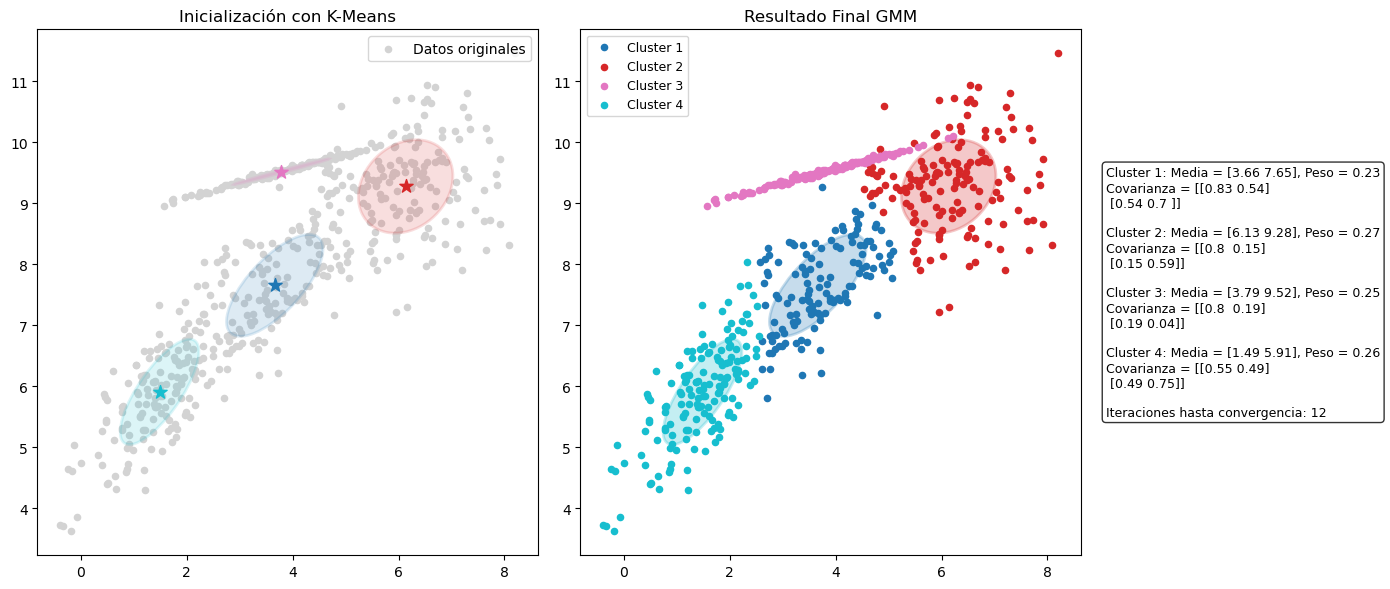

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from matplotlib.patches import Ellipse

# ==========================
# Datos de ejemplo (2D con k clusters)
# ==========================
np.random.seed(42)

kc = 4        # Número de componentes (clusters)
n_points = 150  # Puntos por cluster
d = 2        # Dimensión de los datos

clusters = []
for i in range(kc):
    # Media aleatoria en el rango [0,10)
    mean = np.random.uniform(0, 10, size=d)
    # Matriz de covarianza (simétrica y definida positiva)
    A = np.random.rand(d, d)
    cov = np.dot(A, A.T)  # asegura que sea simétrica y definida positiva
    cluster = np.random.multivariate_normal(mean, cov, n_points)
    clusters.append(cluster)

# Apilar todos los clusters en un solo conjunto
X = np.vstack(clusters)
n, d = X.shape

print(f"Dimensión: {d}, Total de puntos: {n}, Número de clusters: {kc}")


# --- Inicialización con KMeans ---
k = 4
kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
init_means = kmeans.cluster_centers_

# --- Ajustar GMM ---
gmm = GaussianMixture(n_components=k, covariance_type="full", max_iter=200, random_state=42)
gmm.means_init = init_means
gmm.fit(X)
labels = gmm.predict(X)

# ---------------- Función para graficar elipses ----------------
def plot_ellipse(mean, cov, ax, color, label=None, alpha=0.2, linewidth=2):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * np.sqrt(vals)  # escala: 2σ
    ell = Ellipse(xy=mean, width=width, height=height,
                  angle=theta, edgecolor=color, fc=color, lw=linewidth, alpha=alpha, label=label)
    ax.add_patch(ell)

# ---------------- Figura ----------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# === Subplot Izquierdo: Inicialización con K-Means ===
axes[0].scatter(X[:, 0], X[:, 1], c="lightgray", s=20, label="Datos originales")

# Crear paleta de colores con k colores distintos
cmap = plt.colormaps["tab10"].resampled(k)   # también puedes usar "tab20" o "Set1"
colors = [cmap(i) for i in range(k)]

for i, (mean, covar) in enumerate(zip(gmm.means_, gmm.covariances_)):
    plot_ellipse(mean, covar, axes[0], color=colors[i], alpha=0.15, linewidth=2)
    axes[0].scatter(mean[0], mean[1], color=colors[i], marker="*", s=100)

axes[0].set_title("Inicialización con K-Means")
axes[0].legend(loc="upper right")

# === Subplot Derecho: Resultado Final de GMM ===
for i, color in enumerate(colors):
    cluster_points = X[labels == i]
    axes[1].scatter(cluster_points[:, 0], cluster_points[:, 1], s=20, color=color, label=f"Cluster {i+1}")
    plot_ellipse(gmm.means_[i], gmm.covariances_[i], axes[1], color=color, alpha=0.25, linewidth=2)

# Parámetros finales en la leyenda
params_text = "\n".join(
    [f"Cluster {i+1}: Media = {np.round(gmm.means_[i], 2)}, "
     f"Peso = {gmm.weights_[i]:.2f}\n"
     f"Covarianza = {np.round(gmm.covariances_[i], 2)}\n" for i in range(k)]
)
params_text += f"\nIteraciones hasta convergencia: {gmm.n_iter_}"

axes[1].set_title("Resultado Final GMM")
axes[1].legend(loc="upper left", fontsize=9)
axes[1].text(1.05, 0.5, params_text, transform=axes[1].transAxes,
             fontsize=9, verticalalignment="center", bbox=dict(boxstyle="round", fc="w", alpha=0.8))

plt.tight_layout()
plt.show()

### Ejemplo Media-luna

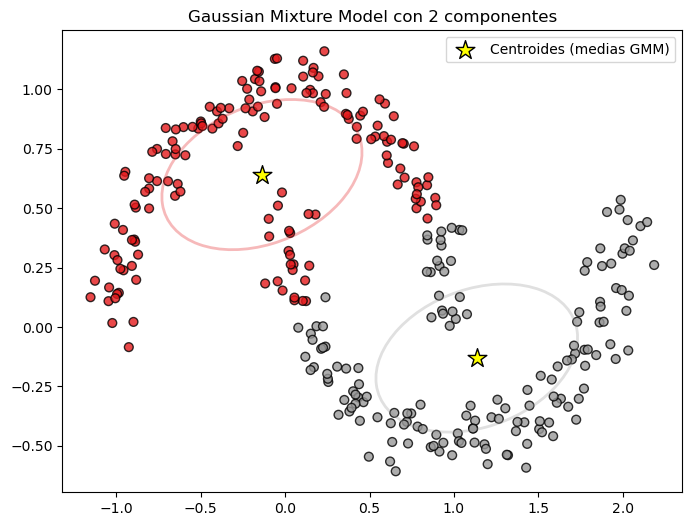

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse

# ================================
# Generar datos de ejemplo
# ================================
X, _ = make_moons(n_samples=300, noise=0.07, random_state=42)

# ================================
# Aplicar GMM
# ================================
k = 2  # número de clusters esperado
gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
gmm.fit(X)

labels = gmm.predict(X)              # Asignación dura
probs = gmm.predict_proba(X)         # Probabilidades por clúster
centroids = gmm.means_               # Medias gaussianas
covariances = gmm.covariances_       # Covarianzas

# ================================
# Función para dibujar elipses
# ================================
def draw_ellipse(mean, cov, ax, color='black', alpha=0.3):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    width, height = 2 * np.sqrt(vals)
    ellip = Ellipse(mean, width, height, angle=theta, edgecolor=color,
                    facecolor='none', lw=2, alpha=alpha)
    ax.add_patch(ellip)

# ================================
# Visualización de clusters con elipses
# ================================
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="Set1", s=40, edgecolor="k", alpha=0.8)
plt.scatter(centroids[:, 0], centroids[:, 1], 
            c="yellow", s=200, marker="*", edgecolor="k", label="Centroides (medias GMM)")

# Dibujar elipses de covarianza
colors = plt.cm.Set1(np.linspace(0, 1, k))
for i in range(k):
    draw_ellipse(centroids[i], covariances[i], plt.gca(), color=colors[i])

plt.title(f"Gaussian Mixture Model con {k} componentes")
plt.legend()
plt.show()

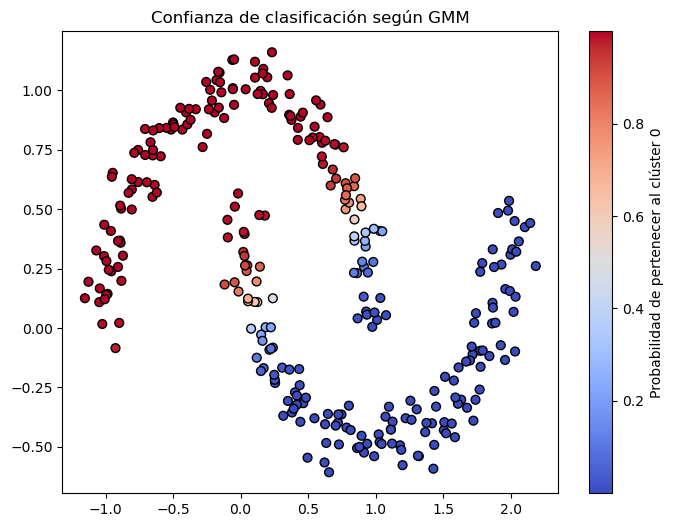

In [19]:
# ================================
# Mostrar probabilidad de pertenencia (opcional)
# ================================
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=probs[:, 0], cmap="coolwarm", s=40, edgecolor="k")
plt.colorbar(label="Probabilidad de pertenecer al clúster 0")
plt.title("Confianza de clasificación según GMM")
plt.show()

## Funcionamiento del código de GMM paso a paso

El código realiza lo siguiente:

1. **Inicialización de las gaussianas:**  
   - Se colocan dos gaussianas inicialmente lejos de los clústeres reales del conjunto de datos.

2. **Iteración del algoritmo EM:**  
   - Se ejecutan los pasos **E-step** y **M-step**, mostrando los cálculos correspondientes en consola.

3. **Visualización en cada iteración:**  
   - Se dibujan los puntos del conjunto de datos, coloreados según la asignación de mayor probabilidad a cada componente.  
   - Se marcan las **medias de cada gaussiana** con una “x” de color negro.  
   - Se trazan **elipses de covarianza** que representan la forma y orientación de cada gaussiana.

4. **Resultado final:**  
   - Se visualiza cómo los centroides y las elipses se ajustan iteración tras iteración, mostrando la convergencia del algoritmo hacia la distribución final de los clústeres.

Iteración 1
Componente 1: peso=0.500, media=[ 0.63541161 -0.88254234], cov=
[[1. 0.]
 [0. 1.]]

Componente 2: peso=0.500, media=[4.5970785  3.55704282], cov=
[[1. 0.]
 [0. 1.]]

Iteración 2
Componente 1: peso=0.500, media=[0.05467431 0.08077485], cov=
[[0.41436266 0.10506314]
 [0.10506314 0.38851371]]

Componente 2: peso=0.500, media=[3.93143588 4.09385159], cov=
[[ 0.54967325 -0.33856174]
 [-0.33856174  0.48442183]]

Iteración 3
Componente 1: peso=0.500, media=[0.05519195 0.08154552], cov=
[[0.41478243 0.10591767]
 [0.10591767 0.38969765]]

Componente 2: peso=0.500, media=[3.93264039 4.09486362], cov=
[[ 0.54664905 -0.34146103]
 [-0.34146103  0.48231029]]

Iteración 4
Componente 1: peso=0.500, media=[0.05519195 0.08154552], cov=
[[0.41478243 0.10591767]
 [0.10591767 0.38969765]]

Componente 2: peso=0.500, media=[3.93264039 4.09486362], cov=
[[ 0.54664905 -0.34146103]
 [-0.34146103  0.48231029]]

Iteración 5
Componente 1: peso=0.500, media=[0.05519195 0.08154552], cov=
[[0.41478243 0.1

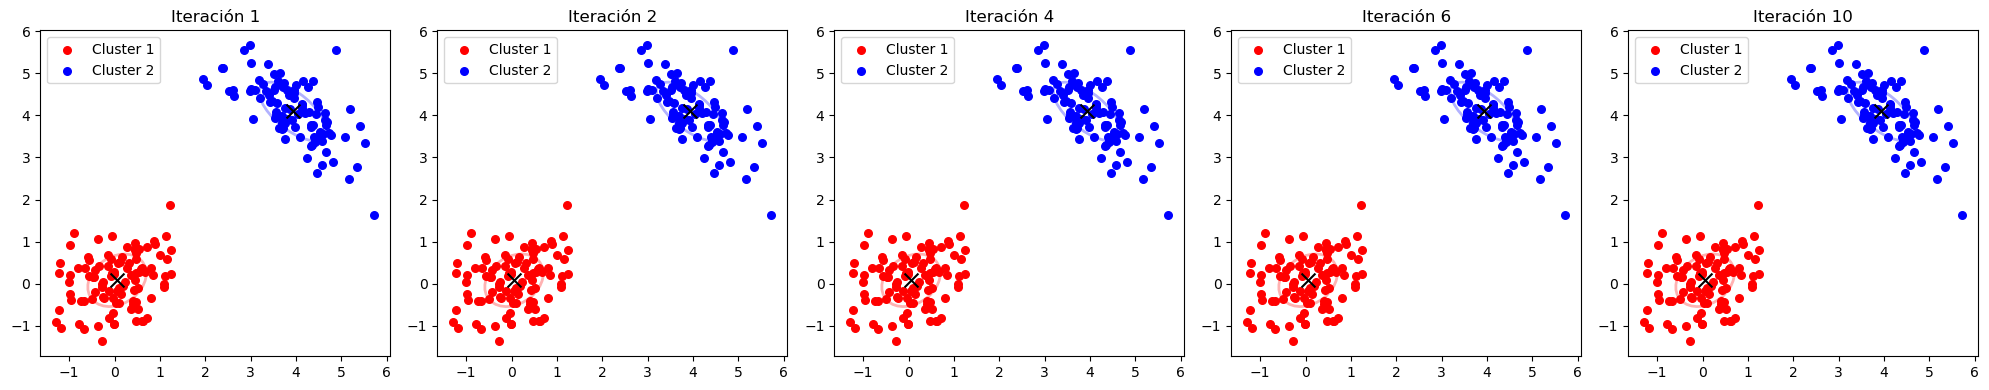

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal

# ==========================
# Generar datos de ejemplo (2 clusters 2D)
# ==========================
np.random.seed(42)
X1 = np.random.multivariate_normal([0, 0], [[0.5, 0.2], [0.2, 0.5]], 100)
X2 = np.random.multivariate_normal([4, 4], [[0.5, -0.3], [-0.3, 0.5]], 100)
X = np.vstack([X1, X2])
n, d = X.shape
k = 2  # número de gaussianas

# ==========================
# Inicialización de parámetros
# ==========================
np.random.seed(0)
means = X[np.random.choice(n, k, replace=False)]
covariances = [np.eye(d) for _ in range(k)]
weights = np.ones(k) / k

# Función para dibujar elipses de covarianza
def draw_ellipse(mean, cov, ax, color='black', alpha=0.3):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    width, height = 2 * np.sqrt(vals)
    ellip = Ellipse(mean, width, height, angle=theta, edgecolor=color,
                    facecolor='none', lw=2, alpha=alpha)
    ax.add_patch(ellip)

# ==========================
# EM manual
# ==========================
def e_step(X, means, covariances, weights):
    N, D = X.shape
    gamma = np.zeros((N, k))
    for j in range(k):
        gamma[:, j] = weights[j] * multivariate_normal.pdf(X, mean=means[j], cov=covariances[j])
    gamma /= gamma.sum(axis=1, keepdims=True)
    return gamma

def m_step(X, gamma):
    N, D = X.shape
    Nk = gamma.sum(axis=0)
    means = (gamma.T @ X) / Nk[:, np.newaxis]
    covariances = []
    for j in range(k):
        diff = X - means[j]
        cov = (gamma[:, j][:, np.newaxis] * diff).T @ diff / Nk[j]
        covariances.append(cov)
    weights = Nk / N
    return means, covariances, weights

# ==========================
# Visualización paso a paso
# ==========================
n_iter = 10
iters_to_plot = [1, 2, 4, 6, 10]
fig, axes = plt.subplots(1, len(iters_to_plot), figsize=(20, 4))
axes = axes.ravel()

for it in range(1, n_iter + 1):
    # E-step
    gamma = e_step(X, means, covariances, weights)
    print(f"Iteración {it}")
    for j in range(k):
        print(f"Componente {j+1}: peso={weights[j]:.3f}, media={means[j]}, cov=\n{covariances[j]}\n")
    
    # M-step
    means, covariances, weights = m_step(X, gamma)
    
    # Graficar solo iteraciones seleccionadas
    if it in iters_to_plot:
        idx = iters_to_plot.index(it)
        ax = axes[idx]
        labels_plot = gamma.argmax(axis=1)
        colors = ['red', 'blue']
        for j, color in enumerate(colors):
            cluster_points = X[labels_plot == j]
            ax.scatter(cluster_points[:,0], cluster_points[:,1], s=30, color=color, label=f'Cluster {j+1}')
            ax.scatter(means[j,0], means[j,1], c='black', marker='x', s=100)
            draw_ellipse(means[j], covariances[j], ax, color=color)
        ax.set_title(f"Iteración {it}")
        ax.legend()

plt.tight_layout()
plt.show()


# PCA

Número de puntos: 10

Puntos: [[2.5 2.4]
 [0.5 0.7]
 [2.2 2.9]
 [1.9 2.2]
 [3.1 3. ]
 [2.3 2.7]
 [2.  1.6]
 [1.  1.1]
 [1.5 1.6]
 [1.1 0.9]]

Media de los datos: [1.81 1.91]

Matriz de covarianza:
 [[0.61655556 0.61544444]
 [0.61544444 0.71655556]]

Eigenvalores: [1.28402771 0.0490834 ]

Eigenvectores (columnas):
 [[ 0.6778734  -0.73517866]
 [ 0.73517866  0.6778734 ]]

Primeros 5 datos proyectados:
 [[ 0.82797019 -0.17511531]
 [-1.77758033  0.14285723]
 [ 0.99219749  0.38437499]
 [ 0.27421042  0.13041721]
 [ 1.67580142 -0.20949846]]


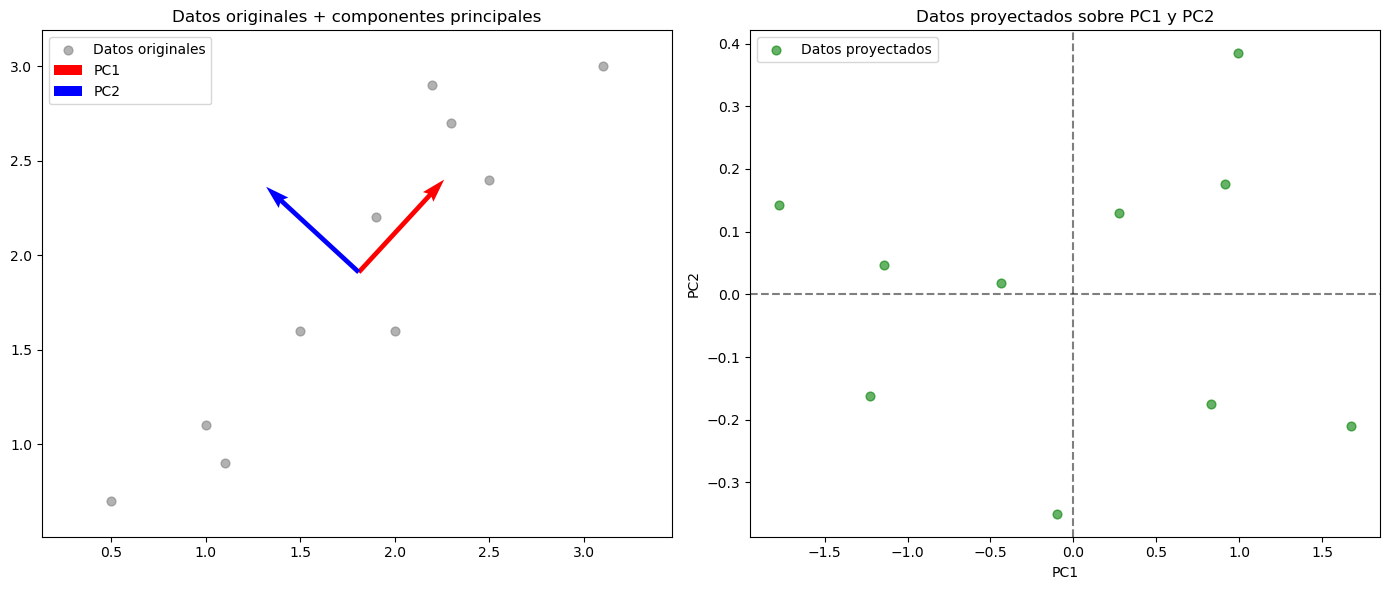


Varianza explicada por cada componente: [0.96318131 0.03681869]
Varianza explicada acumulada: [0.96318131 1.        ]


In [2]:
# ==========================
# PCA paso a paso
# ==========================
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Generar un conjunto de datos ilustrativo (2D)
# --------------------------
np.random.seed(42)

# Tres grupos elípticos distribuidos diagonalmente
X = np.array([[2.5, 2.4],
              [0.5, 0.7],
              [2.2, 2.9],
              [1.9, 2.2],
              [3.1, 3.0],
              [2.3, 2.7],
              [2.0, 1.6],
              [1.0, 1.1],
              [1.5, 1.6],
              [1.1, 0.9]])

n, d = X.shape
print("Número de puntos:", n)
print("\nPuntos:", X)

# --------------------------
# Centralizar los datos
# --------------------------
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean
print("\nMedia de los datos:", X_mean)

# --------------------------
# Matriz de covarianza
# --------------------------
cov_matrix = np.cov(X_centered, rowvar=False)
print("\nMatriz de covarianza:\n", cov_matrix)

# --------------------------
# Eigenvectores y eigenvalores
# --------------------------
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)
sorted_idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_idx]
eig_vecs = eig_vecs[:, sorted_idx]
print("\nEigenvalores:", eig_vals)
print("\nEigenvectores (columnas):\n", eig_vecs)

# --------------------------
# Proyección sobre las primeras 2 componentes
# --------------------------
W = eig_vecs[:, :2]
Z = X_centered @ W
print("\nPrimeros 5 datos proyectados:\n", Z[:5])

# --------------------------
# Visualización
# --------------------------
plt.figure(figsize=(14,6))

# Datos originales con flechas de componentes principales
plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], c='gray', alpha=0.6, s=40, label='Datos originales')
for i, color in enumerate(['red', 'blue']):
    plt.quiver(X_mean[0], X_mean[1], eig_vecs[0,i], eig_vecs[1,i],
               scale=5, color=color, label=f'PC{i+1}')
plt.axis('equal')
plt.title("Datos originales + componentes principales")
plt.legend()

# Datos proyectados sobre PCA
plt.subplot(1,2,2)
plt.scatter(Z[:,0], Z[:,1], c='green', s=40, alpha=0.6, label='Datos proyectados')
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.axvline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Datos proyectados sobre PC1 y PC2")
plt.legend()

plt.tight_layout()
plt.show()

# --------------------------
# Varianza explicada
# --------------------------
var_explained = eig_vals / np.sum(eig_vals)
print("\nVarianza explicada por cada componente:", var_explained)
print("Varianza explicada acumulada:", np.cumsum(var_explained))


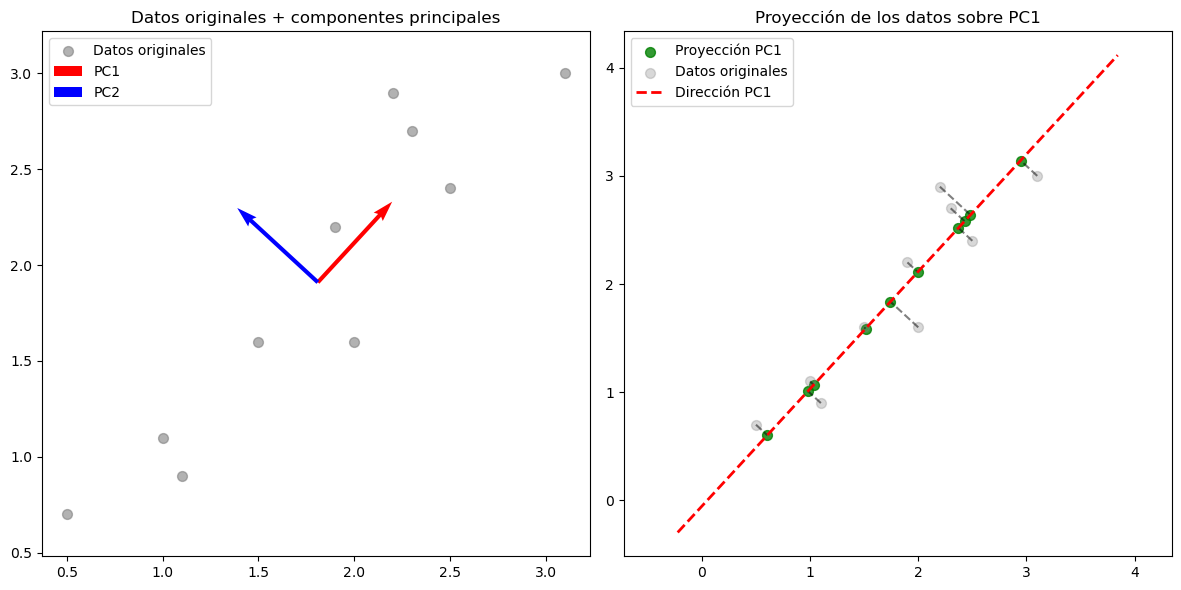

Varianza explicada por cada componente: [0.96318131 0.03681869]
Varianza explicada acumulada: [0.96318131 1.        ]


In [3]:
# --------------------------
# Proyección sobre la primera componente principal
# --------------------------
pc1 = eig_vecs[:, 0].reshape(-1, 1)  # vector columna de la primera componente
Z1 = X_centered @ pc1                 # proyección en PC1
X_proj_line = Z1 @ pc1.T + X_mean    # reconstrucción de los puntos proyectados

# Línea punteada de la dirección de PC1
line_range = np.linspace(-3, 3, 100)
pc1_line = X_mean + line_range[:, np.newaxis] * pc1.T

# --------------------------
# Visualización
# --------------------------
plt.figure(figsize=(12,6))

# Subplot 1: datos originales con flechas de PC
plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], c='gray', alpha=0.6, s=50, label='Datos originales')
origin = X_mean
plt.quiver(*origin, *eig_vecs[:,0], color='red', scale=5, label='PC1')
plt.quiver(*origin, *eig_vecs[:,1], color='blue', scale=5, label='PC2')
plt.axis('equal')
plt.title("Datos originales + componentes principales")
plt.legend()

# Subplot 2: datos proyectados sobre PC1
plt.subplot(1,2,2)
plt.scatter(X_proj_line[:,0], X_proj_line[:,1], c='green', s=50, alpha=0.8, label='Proyección PC1')
plt.scatter(X[:,0], X[:,1], c='gray', alpha=0.3, s=50, label='Datos originales')
for i in range(X.shape[0]):
    plt.plot([X[i,0], X_proj_line[i,0]], [X[i,1], X_proj_line[i,1]], 'k--', alpha=0.5)

# Dibujar línea punteada de la primera componente
plt.plot(pc1_line[:,0], pc1_line[:,1], 'r--', linewidth=2, label='Dirección PC1')

plt.axis('equal')
plt.title("Proyección de los datos sobre PC1")
plt.legend()

plt.tight_layout()
plt.show()

# --------------------------
# 6. Varianza explicada
# --------------------------
var_explained = eig_vals / np.sum(eig_vals)
print("Varianza explicada por cada componente:", var_explained)
print("Varianza explicada acumulada:", np.cumsum(var_explained))

Tamaño original de los datos: (200, 120)
Tamaño después de PCA: (200, 70)
Número de componentes seleccionadas: 70
Varianza explicada acumulada: 0.9511397525628448


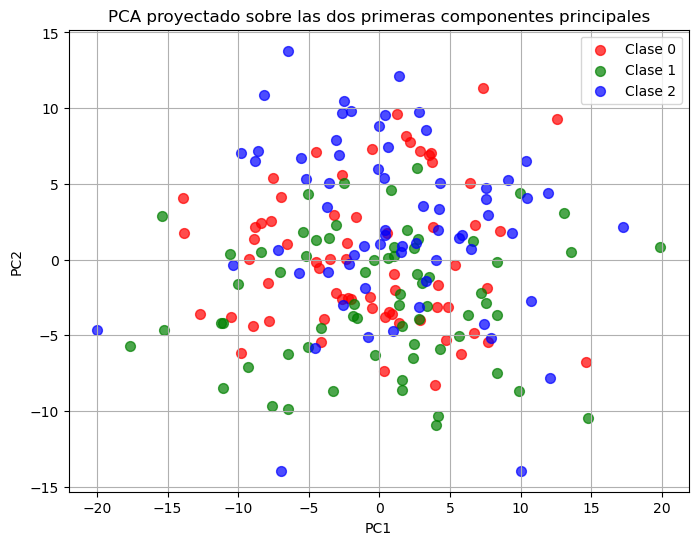

In [4]:
# ==========================
# PCA con datos de alta dimensión (>100 features)
# ==========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import make_classification

# --------------------------
# Generar datos sintéticos de alta dimensión
# --------------------------
np.random.seed(42)
X, y = make_classification(n_samples=200, n_features=120, n_informative=10,
                           n_redundant=10, n_classes=3, random_state=42)

print("Tamaño original de los datos:", X.shape)

# --------------------------
# Aplicar PCA para conservar el 95% de la varianza
# --------------------------
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X)

print("Tamaño después de PCA:", X_pca.shape)
print("Número de componentes seleccionadas:", X_pca.shape[1])
print("Varianza explicada acumulada:", np.sum(pca.explained_variance_ratio_))

# --------------------------
# Visualización en 2D (primeras dos componentes)
# --------------------------
plt.figure(figsize=(8,6))
colors = ['red', 'green', 'blue']

for i, color in zip(range(3), colors):
    plt.scatter(X_pca[y==i, 0], X_pca[y==i, 1], c=color, label=f'Clase {i}', alpha=0.7, s=50)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA proyectado sobre las dos primeras componentes principales")
plt.legend()
plt.grid(True)
plt.show()


Tamaño original de los datos: (1797, 64)
Tamaño después de PCA: (1797, 29)
Número de componentes seleccionadas: 29
Varianza explicada acumulada: 0.9547965245651595


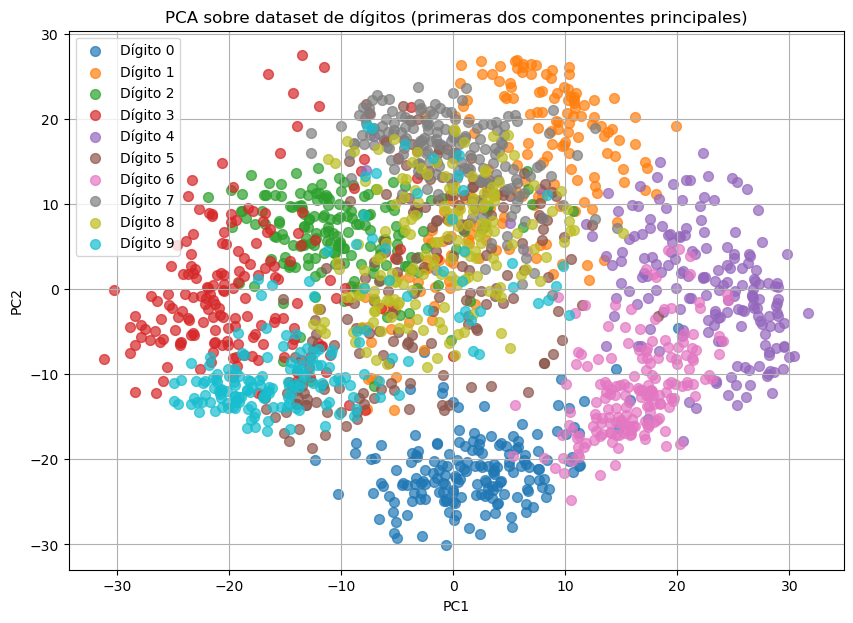

In [5]:
# ==========================
# PCA sobre el dataset de dígitos
# ==========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

# --------------------------
# Cargar el dataset
# --------------------------
digits = load_digits()
X = digits.data      # 1797 x 64
y = digits.target

print("Tamaño original de los datos:", X.shape)

# --------------------------
# Aplicar PCA para conservar el 95% de la varianza
# --------------------------
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X)

print("Tamaño después de PCA:", X_pca.shape)
print("Número de componentes seleccionadas:", X_pca.shape[1])
print("Varianza explicada acumulada:", np.sum(pca.explained_variance_ratio_))

# --------------------------
# Visualización en 2D (primeras dos componentes)
# --------------------------
plt.figure(figsize=(10,7))
for digit in np.unique(y):
    plt.scatter(X_pca[y==digit, 0], X_pca[y==digit, 1], s=50, alpha=0.7, label=f'Dígito {digit}')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA sobre dataset de dígitos (primeras dos componentes principales)")
plt.legend()
plt.grid(True)
plt.show()


# LDA (Linear Discriminant Analysis)

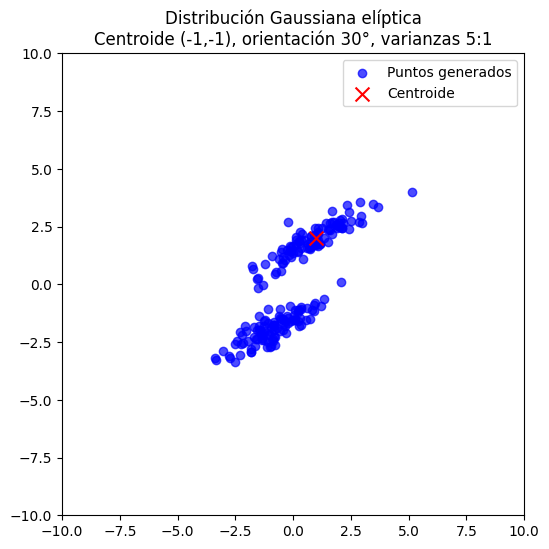

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Número de puntos
n = 100

# Varianzas proporcionales 20:1
var1, var2 = 2, 0.1  # ejes principales

# Ángulo de rotación (30 grados en radianes)
theta = np.deg2rad(30)

# Matriz de rotación
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# Matriz de covarianza en el sistema rotado
D = np.diag([var1, var2])   # matriz diagonal de varianzas
cov = R @ D @ R.T           # matriz de covarianza rotada

# Media (centroide)
mean = np.array([-1, -2])

# Generar puntos
X1 = np.random.multivariate_normal(mean, cov, size=n)

# Media (centroide)
mean = np.array([1, 2])

# Generar puntos
X2 = np.random.multivariate_normal(mean, cov, size=n)

# Unir los dos conjuntos en uno solo
X = np.vstack((X1, X2))

# Graficar
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], alpha=0.7, color="blue", label="Puntos generados")
plt.scatter(mean[0], mean[1], color="red", marker="x", s=100, label="Centroide")

# Fijar los ejes de -10 a 10 sin importar los valores generados
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.gca().set_aspect("equal", adjustable="box")

plt.legend()
plt.title("Distribución Gaussiana elíptica\nCentroide (-1,-1), orientación 30°, varianzas 5:1")
plt.show()


## Solución PCA

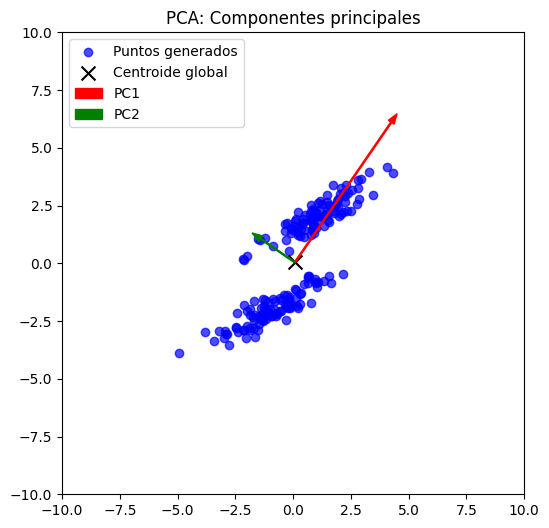

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Número de puntos
n = 100

# Varianzas proporcionales 20:1
var1, var2 = 2, 0.1  # ejes principales

# Ángulo de rotación (30 grados en radianes)
theta = np.deg2rad(30)

# Matriz de rotación
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# Matriz de covarianza en el sistema rotado
D = np.diag([var1, var2])   # matriz diagonal de varianzas
cov = R @ D @ R.T           # matriz de covarianza rotada

# Media (centroide)
mean1 = np.array([-1, -2])
X1 = np.random.multivariate_normal(mean1, cov, size=n)

# Otra nube
mean2 = np.array([1, 2])
X2 = np.random.multivariate_normal(mean2, cov, size=n)

# Unir los dos conjuntos en uno solo
X = np.vstack((X1, X2))

# ----------------------------
# PCA
# ----------------------------
# Centrar datos
X_centered = X - np.mean(X, axis=0)

# Matriz de covarianza
cov_matrix = np.cov(X_centered, rowvar=False)

# Autovalores y autovectores
eigvals, eigvecs = np.linalg.eigh(cov_matrix)

# Ordenar en función de autovalores (de mayor a menor)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# ----------------------------
# Graficar
# ----------------------------
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], alpha=0.7, color="blue", label="Puntos generados")

# Centro de la nube (media global)
mean_global = np.mean(X, axis=0)
plt.scatter(mean_global[0], mean_global[1], color="black", marker="x", s=100, label="Centroide global")

# Colores para los componentes principales
colors = ["red", "green"]

# Dibujar componentes principales
for i in range(2):
    vector = eigvecs[:, i] * np.sqrt(eigvals[i]) * 3
    plt.arrow(mean_global[0], mean_global[1],
              vector[0], vector[1],
              color=colors[i], width=0.05, head_width=0.3, length_includes_head=True,
              label=f"PC{i+1}")

# Fijar límites de visualización
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.gca().set_aspect("equal", adjustable="box")

plt.legend()
plt.title("PCA: Componentes principales")
plt.show()


## Solución LDA

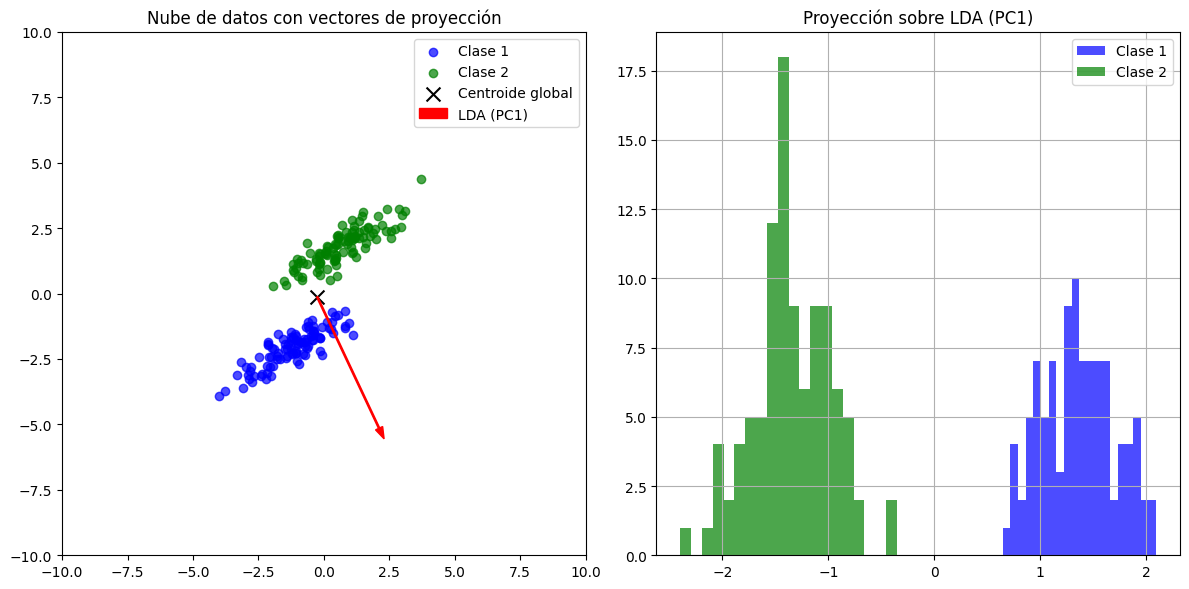

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Número de puntos
n = 100

# Varianzas proporcionales 20:1
var1, var2 = 2, 0.1  # ejes principales

# Ángulo de rotación (30 grados en radianes)
theta = np.deg2rad(30)

# Matriz de rotación
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# Matriz de covarianza en el sistema rotado
D = np.diag([var1, var2])   # matriz diagonal de varianzas
cov = R @ D @ R.T           # matriz de covarianza rotada

# Clase 1
mean1 = np.array([-1, -2])
X1 = np.random.multivariate_normal(mean1, cov, size=n)
y1 = np.zeros(n)

# Clase 2
mean2 = np.array([1, 2])
X2 = np.random.multivariate_normal(mean2, cov, size=n)
y2 = np.ones(n)

# Unir los dos conjuntos
X = np.vstack((X1, X2))
y = np.hstack((y1, y2))

# ----------------------------
# LDA
# ----------------------------
# Medias de cada clase
mean1 = np.mean(X1, axis=0)
mean2 = np.mean(X2, axis=0)

# Media global
mean_global = np.mean(X, axis=0)

# Matriz de dispersión intra-clases (Sw)
S1 = (X1 - mean1).T @ (X1 - mean1)
S2 = (X2 - mean2).T @ (X2 - mean2)
Sw = S1 + S2

# Matriz de dispersión entre clases (Sb)
mean_diff = (mean1 - mean2).reshape(-1,1)
Sb = mean_diff @ mean_diff.T

# Resolver el problema generalizado: inv(Sw) * Sb
eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(Sw) @ Sb)

# Ordenar
idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, idx]

# Primer discriminante lineal (LDA)
w1 = eigvecs[:,0].real
w1 = w1 / np.linalg.norm(w1)

# Segundo vector: ortogonal a w1
w2 = np.array([-w1[1], w1[0]])  # rotación de 90 grados
w2 = w2 / np.linalg.norm(w2)

# ----------------------------
# Proyección sobre LDA
# ----------------------------
proj1 = X @ w1  # proyección en la primera componente
proj2 = X @ w2  # proyección en la segunda componente (no LDA, solo ortogonal)

# ----------------------------
# Graficar
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# --- Gráfico 1: nube con vectores ---
axes[0].scatter(X1[:,0], X1[:,1], alpha=0.7, color="blue", label="Clase 1")
axes[0].scatter(X2[:,0], X2[:,1], alpha=0.7, color="green", label="Clase 2")
axes[0].scatter(mean_global[0], mean_global[1], color="black", marker="x", s=100, label="Centroide global")

# Dibujar vectores
for vec, col, name in [(w1, "red", "LDA (PC1)")]:
    v = vec * 6
    axes[0].arrow(mean_global[0], mean_global[1],
                  v[0], v[1],
                  color=col, width=0.05, head_width=0.3, length_includes_head=True,
                  label=name)

axes[0].set_xlim(-10, 10)
axes[0].set_ylim(-10, 10)
axes[0].set_aspect("equal", adjustable="box")
axes[0].legend()
axes[0].set_title("Nube de datos con vectores de proyección")

# --- Gráfico 2: proyección en la primera componente (LDA) ---
axes[1].hist(proj1[y==0], bins=20, alpha=0.7, color="blue", label="Clase 1")
axes[1].hist(proj1[y==1], bins=20, alpha=0.7, color="green", label="Clase 2")
axes[1].set_title("Proyección sobre LDA (PC1)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


# Técnica t-SNE (t-distributed Stochastic Neighbor Embedding)

Cargando MNIST...
Tamaño original de X: (2000, 784)
Aplicando t-SNE...
Tamaño después de t-SNE: (2000, 2)


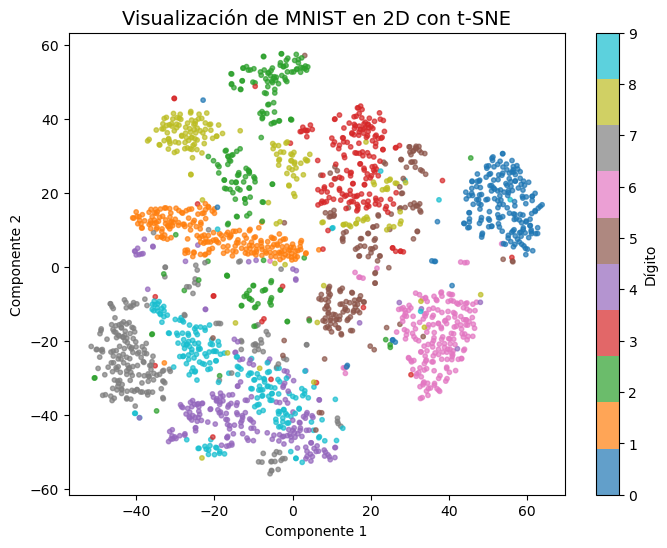

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# Cargar el dataset MNIST desde openml
print("Cargando MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"].astype(int)

# Para hacerlo más rápido tomamos una muestra (ejemplo: 2000 imágenes)
n_samples = 2000
X, y = X[:n_samples], y[:n_samples]

# Imprimir tamaño original
print(f"Tamaño original de X: {X.shape}")

# Aplicar t-SNE para reducir de 784 dimensiones a 2
print("Aplicando t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X)

# Imprimir tamaño reducido
print(f"Tamaño después de t-SNE: {X_tsne.shape}")

# Graficar resultados
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", s=10, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label="Dígito")
plt.title("Visualización de MNIST en 2D con t-SNE", fontsize=14)
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()


### Distribución de probabilidad por cluster

In [8]:

# Definir número de clusters (ejemplo: 10 como el número de dígitos)
K = 10

# Clustering en espacio original (784D)
kmeans_original = KMeans(n_clusters=K, random_state=42)
clusters_original = kmeans_original.fit_predict(X)

# Distribución en espacio original
dist_original = pd.Series(clusters_original).value_counts(normalize=True).sort_index()


# Clustering en espacio reducido (2D)
kmeans_reducido = KMeans(n_clusters=K, random_state=42)
clusters_reducido = kmeans_reducido.fit_predict(X_tsne)

# Distribución en espacio reducido
dist_reducida = pd.Series(clusters_reducido).value_counts(normalize=True).sort_index()

# Crear tabla comparativa
tabla = pd.DataFrame({
    "Cluster": range(K),
    "Probabilidad antes de t-SNE": dist_original.values,
    "Probabilidad después de t-SNE": dist_reducida.values
})

print("\nDistribución de probabilidad por cluster (comparativa):")
print(tabla.to_string(index=False))




Distribución de probabilidad por cluster (comparativa):
 Cluster  Probabilidad antes de t-SNE  Probabilidad después de t-SNE
       0                       0.1175                         0.0950
       1                       0.0955                         0.0625
       2                       0.0855                         0.0820
       3                       0.1640                         0.1355
       4                       0.0930                         0.1470
       5                       0.1030                         0.0960
       6                       0.0845                         0.0780
       7                       0.0645                         0.1045
       8                       0.1180                         0.1205
       9                       0.0745                         0.0790


# Técnica UMAP (Uniform Manifold Approximation and Projection)

In [4]:
#import sys
#!{sys.executable} -m pip install umap-learn

C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargando MNIST...
Conjunto reducido a 5000 imágenes
Aplicando UMAP...


C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


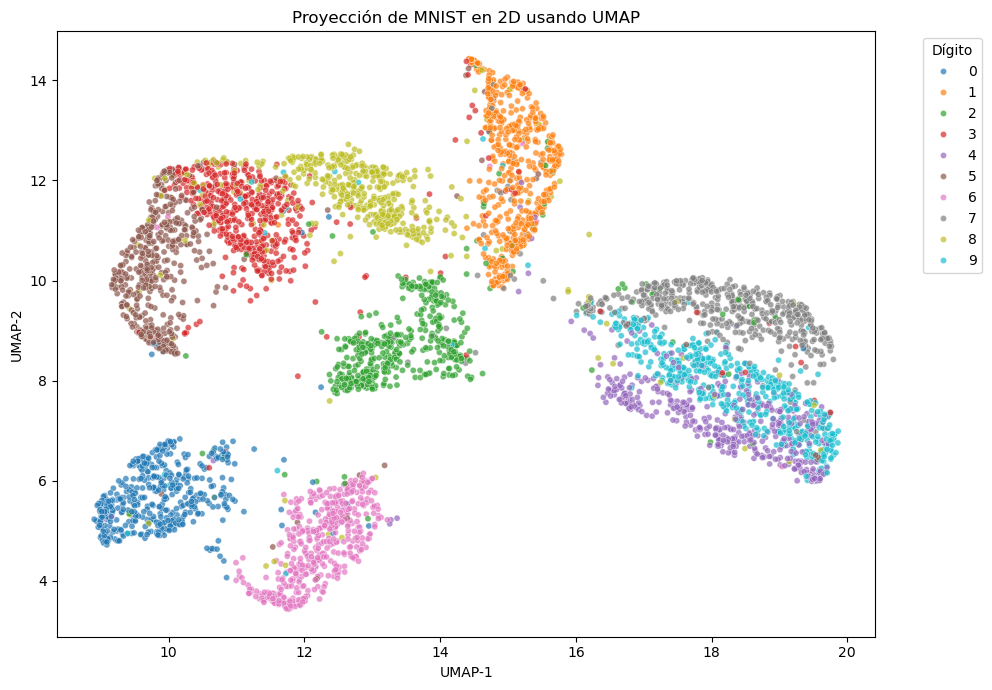

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
import umap

# Cargar MNIST desde OpenML
print("Cargando MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"].astype(int)

# Para acelerar el ejemplo usamos una muestra
n_samples = 5000
np.random.seed(42)
indices = np.random.choice(len(X), n_samples, replace=False)
X_sample = X[indices]
y_sample = y[indices]

print(f"Conjunto reducido a {n_samples} imágenes")

# Reducir con UMAP
print("Aplicando UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_sample)

# Visualizar
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_umap[:, 0], y=X_umap[:, 1],
    hue=y_sample, palette="tab10", s=20, alpha=0.7, legend="full"
)
plt.title("Proyección de MNIST en 2D usando UMAP")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Dígito", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# Autoencoders para reducción de dimensionalidad

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3201 - val_loss: 0.1391
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1306 - val_loss: 0.1094
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1079 - val_loss: 0.0993
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0992 - val_loss: 0.0943
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0947 - val_loss: 0.0908
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0915 - val_loss: 0.0884
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0889 - val_loss: 0.0864
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0870 - val_loss: 0.0849
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0854 - val_loss: 0.0833
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0841 - val_loss: 0.0822
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Forma original: (60000, 784)
Forma reducida: (60000, 64

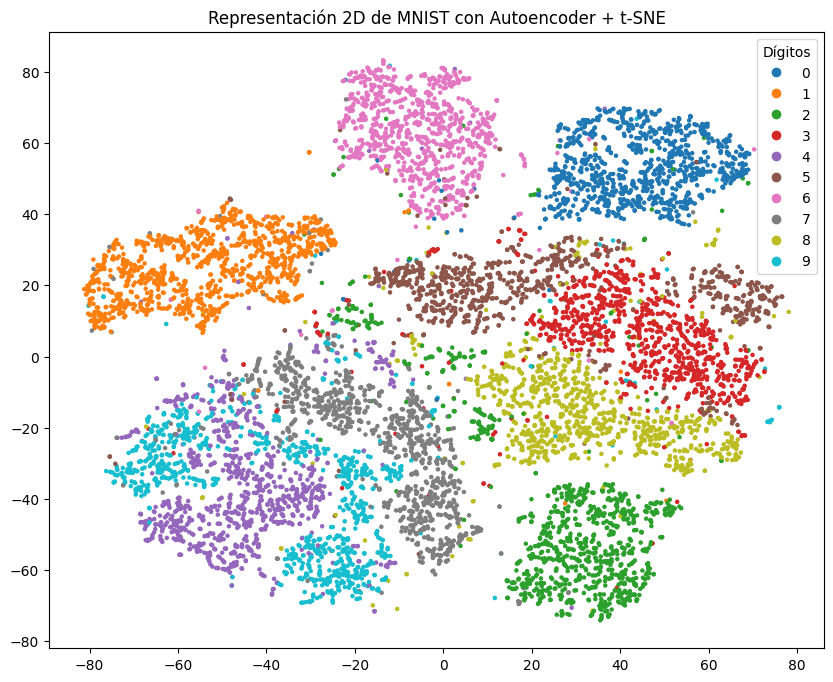

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


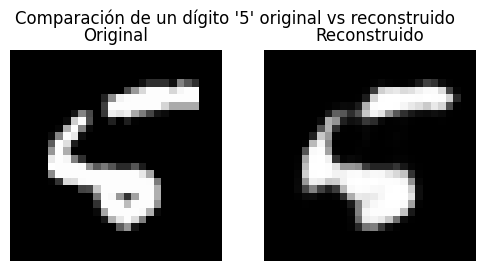

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.manifold import TSNE

# ------------------------------------------------
# Cargar datos MNIST
# ------------------------------------------------
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Aplanar las imágenes (28x28 -> 784)
x_train = x_train.reshape((len(x_train), -1))
x_test = x_test.reshape((len(x_test), -1))

# ------------------------------------------------
# Definir el Autoencoder
# ------------------------------------------------
input_dim = x_train.shape[1]  # 784
encoding_dim = 64             # espacio reducido

input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation="relu")(input_layer)
encoded = Dense(encoding_dim, activation="relu")(encoded)
decoded = Dense(128, activation="relu")(encoded)
decoded = Dense(input_dim, activation="sigmoid")(decoded)

autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# ------------------------------------------------
# Reducir la dimensión
# ------------------------------------------------
x_train_encoded = encoder.predict(x_train)
x_test_encoded = encoder.predict(x_test)

print("Forma original:", x_train.shape)
print("Forma reducida:", x_train_encoded.shape)

# ------------------------------------------------
# Visualización t-SNE del espacio latente
# ------------------------------------------------
x_vis = TSNE(n_components=2, random_state=42).fit_transform(x_test_encoded)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x_vis[:, 0], x_vis[:, 1], c=y_test, cmap="tab10", s=5)
plt.legend(*scatter.legend_elements(), title="Dígitos")
plt.title("Representación 2D de MNIST con Autoencoder + t-SNE")
plt.show()

# ------------------------------------------------
# Visualizar dígito 5 original vs reconstruido
# ------------------------------------------------
# Seleccionar el primer dígito 5 del conjunto de prueba
idx_5 = np.where(y_test == 5)[0][0]
original_5 = x_test[idx_5].reshape(28,28)
reconstructed_5 = autoencoder.predict(x_test[idx_5].reshape(1,-1)).reshape(28,28)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(original_5, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(reconstructed_5, cmap='gray')
plt.title("Reconstruido")
plt.axis('off')

plt.suptitle("Comparación de un dígito '5' original vs reconstruido")
plt.show()


# AQUI